<a href="https://colab.research.google.com/github/BHARATH-RAJ-B-L/Maaven-CI/blob/main/Deep_Learning_for_Traffic_Sign_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
<strong>
    <h1 align='center'>Classify Traffic Signs Using Deep Learning for Self-Driving Cars</h1>
</strong>

---



- Task 1: Project Overview
- Task 2: Import Libraries and datasets
- Task 3: Perform image visualization
- Task 4: Convert images to gray-scale and perform normalization
- Task 5: Understand the theory and intuition behind Convolutional Neural Networks
- Task 6: Build a deep convolutional network model using Keras
- Task 7: Compile and train deep convolutional network model
- Task 8: Assess trained model performance

## __Task 1:__ Project Overview


<p align='center'>
  <a href="#"><img src='https://raw.githubusercontent.com/mohd-faizy/01P_Project_Deep_Learning_for_Traffic_Sign_Classification/master/Proj_png/01.png' height='400' width='900'></a>
</p>

<p align='center'>
  <a href="#"><img src='https://raw.githubusercontent.com/mohd-faizy/01P_Project_Deep_Learning_for_Traffic_Sign_Classification/master/Proj_png/02.png' height='400' width='900'></a>
</p>

## __Task 2:__ Importing Libraries/Datasets

In [1]:
! wget https://www.dropbox.com/s/v2r77l4wgfkrb1r/traffic_signs_data.zip

--2025-11-09 09:18:17--  https://www.dropbox.com/s/v2r77l4wgfkrb1r/traffic_signs_data.zip
Resolving www.dropbox.com (www.dropbox.com)... 162.125.1.18, 2620:100:6016:18::a27d:112
Connecting to www.dropbox.com (www.dropbox.com)|162.125.1.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://www.dropbox.com/scl/fi/ibuax6kya537ofspf4a1k/traffic_signs_data.zip?rlkey=67mz7ku45mpqky178na4pxzix [following]
--2025-11-09 09:18:18--  https://www.dropbox.com/scl/fi/ibuax6kya537ofspf4a1k/traffic_signs_data.zip?rlkey=67mz7ku45mpqky178na4pxzix
Reusing existing connection to www.dropbox.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://uc5ecf6b6fb5c8bf5352b0a54feb.dl.dropboxusercontent.com/cd/0/inline/C03vm2vbYrX2FWyY6mD0eIf5MPiXuKNxXu-tGq93DTDSfsIaOK2iDMMvq22Cugz82pq4-YmYLEVdRjo9gY4QqhU55QM-U5yvTht6kNKqq9Kk3wMAp_qoWMKi9RoqNeU4nBy7W_JW3EpX3yq5m2jy-QlX/file# [following]
--2025-11-09 09:18:18--  https://uc5ecf6b6fb5c8bf5352b0a54feb.dl.dropbo

In [2]:
ls

sample_data/  traffic_signs_data.zip


In [3]:
! unzip -uq '/content/traffic_signs_data.zip' -d '/content'

In [4]:
ls

sample_data/  test.p  traffic_signs_data.zip  train.p  valid.p


In [5]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import pickle
import random

print(tf.__version__)

2.19.0


<p align='center'>
  <a href="#"><img src='https://raw.githubusercontent.com/mohd-faizy/01P_Project_Deep_Learning_for_Traffic_Sign_Classification/master/Proj_png/03.png' height='400' width='900'>
</a>
</p>

In [6]:
with open("/content/train.p", mode='rb') as training_data:
    train = pickle.load(training_data)
with open("/content/valid.p", mode='rb') as validation_data:
    valid = pickle.load(validation_data)
with open("/content/test.p", mode='rb') as testing_data:
    test = pickle.load(testing_data)

In [7]:
X_train, y_train = train['features'], train['labels']
X_validation, y_validation = valid['features'], valid['labels']
X_test, y_test = test['features'], test['labels']

In [8]:
X_train.shape

(34799, 32, 32, 3)

In [9]:
y_train.shape

(34799,)

## __Task 3:__ Perform Images Visualization

np.uint8(2)

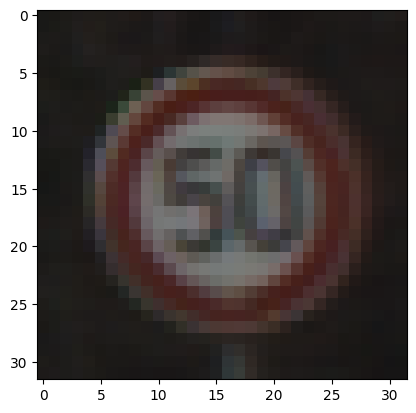

In [10]:
i = np.random.randint(1, len(X_train))
plt.imshow(X_train[i])
y_train[i]

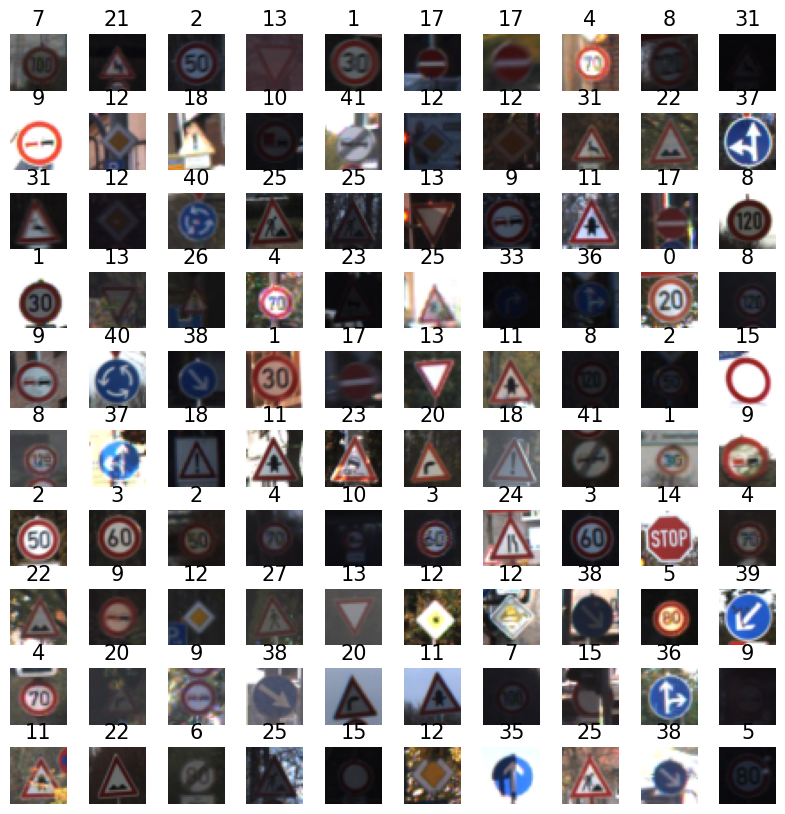

In [11]:
# Let's view more images in a grid format
# Define the dimensions of the plot grid
W_grid = 10
L_grid = 10

# fig, axes = plt.subplots(L_grid, W_grid)
# subplot return the figure object and axes object
# we can use the axes object to plot specific figures at various locations

fig, axes = plt.subplots(L_grid, W_grid, figsize = (10,10))

axes = axes.ravel() # flaten the 15 x 15 matrix into 225 array

n_training = len(X_train) # get the length of the training dataset

# Select a random number from 0 to n_training
for i in np.arange(0, W_grid * L_grid): # create evenly spaces variables

    # Select a random number
    index = np.random.randint(0, n_training)
    # read and display an image with the selected index
    axes[i].imshow( X_train[index])
    axes[i].set_title(y_train[index], fontsize = 15)
    axes[i].axis('off')

plt.subplots_adjust(hspace=0.4)

## __Task 4:__ Convert Images to grayscale and Perform Normalization

In [12]:
from sklearn.utils import shuffle
X_train, y_train = shuffle(X_train, y_train)

In [13]:
X_train_gray = np.sum(X_train/3, axis = 3, keepdims = True)
X_test_gray = np.sum(X_test/3, axis = 3, keepdims = True)
X_validation_gray = np.sum(X_validation/3, axis = 3, keepdims = True)

In [14]:
X_train_gray.shape


(34799, 32, 32, 1)

In [15]:
X_test_gray.shape


(12630, 32, 32, 1)

In [16]:
X_validation_gray.shape

(4410, 32, 32, 1)

In [17]:
X_train_gray_norm = (X_train_gray - 128)/128
X_test_gray_norm = (X_test_gray - 128)/128
X_validation_gray_norm = (X_validation_gray - 128)/128

In [18]:
X_train_gray_norm

array([[[[-0.59375   ],
         [-0.66927083],
         [-0.63541667],
         ...,
         [-0.14322917],
         [-0.05208333],
         [-0.04166667]],

        [[-0.60677083],
         [-0.640625  ],
         [-0.65885417],
         ...,
         [-0.09375   ],
         [-0.015625  ],
         [ 0.15885417]],

        [[-0.45833333],
         [-0.59375   ],
         [-0.66927083],
         ...,
         [-0.140625  ],
         [-0.21875   ],
         [-0.11458333]],

        ...,

        [[-0.39322917],
         [-0.56510417],
         [-0.6015625 ],
         ...,
         [-0.20833333],
         [-0.21875   ],
         [-0.06510417]],

        [[-0.50260417],
         [-0.23177083],
         [-0.48697917],
         ...,
         [ 0.05989583],
         [ 0.01822917],
         [ 0.01302083]],

        [[-0.11458333],
         [ 0.21875   ],
         [-0.2578125 ],
         ...,
         [-0.171875  ],
         [-0.04166667],
         [-0.02864583]]],


       [[[ 0.9765625 ],


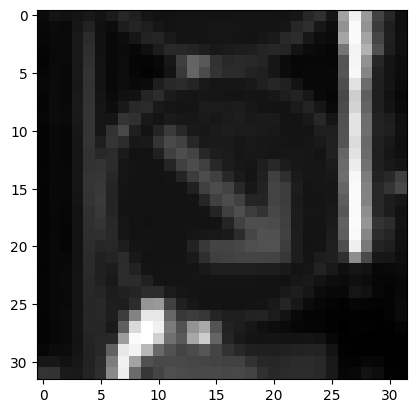

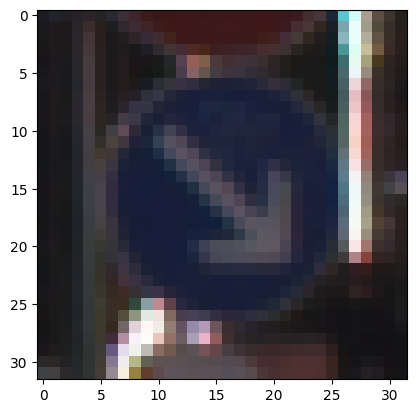

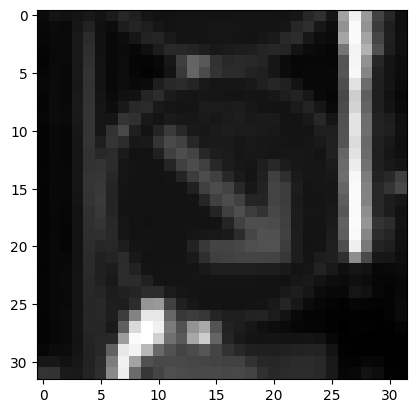

In [19]:
i = random.randint(1, len(X_train_gray))
plt.imshow(X_train_gray[i].squeeze(), cmap = 'gray')
plt.figure()
plt.imshow(X_train[i])
plt.figure()
plt.imshow(X_train_gray_norm[i].squeeze(), cmap = 'gray')

## __Task 5:__ Understand the theory and intution brhind Convolution Neural Network

<p align='center'>
  <a href="#"><img src='https://raw.githubusercontent.com/mohd-faizy/01P_Project_Deep_Learning_for_Traffic_Sign_Classification/master/Proj_png/04.png' height='400' width='900'>
</a>
</p>

<p align='center'>
  <a href="#"><img src='https://raw.githubusercontent.com/mohd-faizy/01P_Project_Deep_Learning_for_Traffic_Sign_Classification/master/Proj_png/05.png' height='400' width='900'></a>
</p>


## __Task 6:__ Build Deep Convolution Neural Network Model

In [22]:
from tensorflow.keras import datasets, layers, models
import tensorflow as tf

model = models.Sequential()

# Using tf.keras.Input as the first layer is the recommended practice
model.add(tf.keras.Input(shape=(32,32,1)))
model.add(layers.Conv2D(6, (5,5), activation = 'relu'))
model.add(layers.AveragePooling2D(pool_size=(2,2)))
#model.add(layers.Dropout(0.2))
model.add(layers.Conv2D(16, (5,5), activation = 'relu'))
model.add(layers.AveragePooling2D(pool_size=(2,2)))
model.add(layers.Flatten())
model.add(layers.Dense(120, activation = 'relu'))
model.add(layers.Dense(84, activation = 'relu'))
model.add(layers.Dense(43, activation = 'softmax'))

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_2             │ (None, 14, 14, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 10, 10, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_3             │ (None, 5, 5, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 120)            │        48,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 43)             │         3,655 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 64,511 (252.00 KB)

 Trainable params: 64,511 (252.00 KB)

 Non-trainable params: 0 (0.00 B)

## __Task 7:__ Compile and Train Deep CNN Model

In [23]:
model.compile(optimizer = 'Adam', loss = 'sparse_categorical_crossentropy', metrics = ['accuracy'])

In [24]:
history = model.fit(X_train_gray_norm,
                 y_train,
                 batch_size = 500,
                 epochs = 50,
                 verbose = 1,
                 validation_data = (X_validation_gray_norm, y_validation))

Epoch 1/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 8s 46ms/step - accuracy: 0.1017 - loss: 3.4400 - val_accuracy: 0.3234 - val_loss: 2.4757
Epoch 2/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4978 - loss: 1.8240 - val_accuracy: 0.6011 - val_loss: 1.3279
Epoch 3/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7258 - loss: 0.9575 - val_accuracy: 0.7066 - val_loss: 0.9872
Epoch 4/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8232 - loss: 0.6477 - val_accuracy: 0.7726 - val_loss: 0.7984
Epoch 5/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8622 - loss: 0.5085 - val_accuracy: 0.7821 - val_loss: 0.7390
Epoch 6/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8893 - loss: 0.4113 - val_accuracy: 0.8039 - val_loss: 0.6912
Epoch 7/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9115 - loss: 0.3420 - val_accuracy: 0.8195 - val_loss: 0.6376
Epoch 8/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9265 - loss: 0.2917 - val_accuracy: 0.8288 - val_loss

## __Task 8:__ Assess Trained CNN Model Performance

In [25]:
score = model.evaluate(X_test_gray_norm, y_test)
print('Test Accuracy: {}'.format(score[1]))

395/395 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8649 - loss: 1.2988
Test Accuracy: 0.8673000931739807


In [26]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [27]:
accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

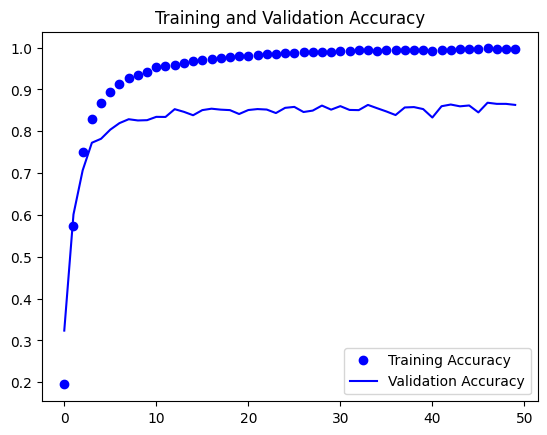

In [28]:
epochs = range(len(accuracy))

plt.plot(epochs, accuracy, 'bo', label='Training Accuracy')
plt.plot(epochs, val_accuracy, 'b', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

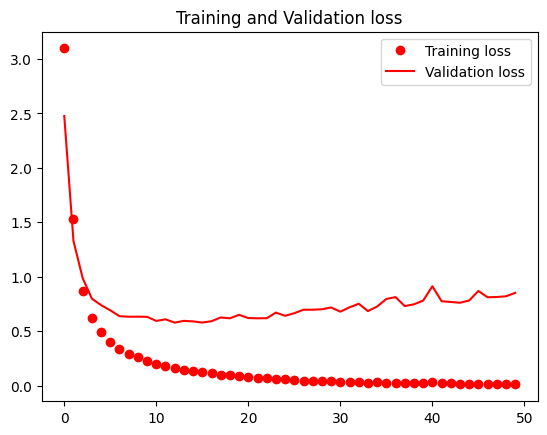

In [29]:
plt.plot(epochs, loss, 'ro', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and Validation loss')
plt.legend()

In [31]:
predicted_classes = np.argmax(model.predict(X_test_gray_norm), axis=-1)
y_true = y_test

395/395 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


<Axes: >

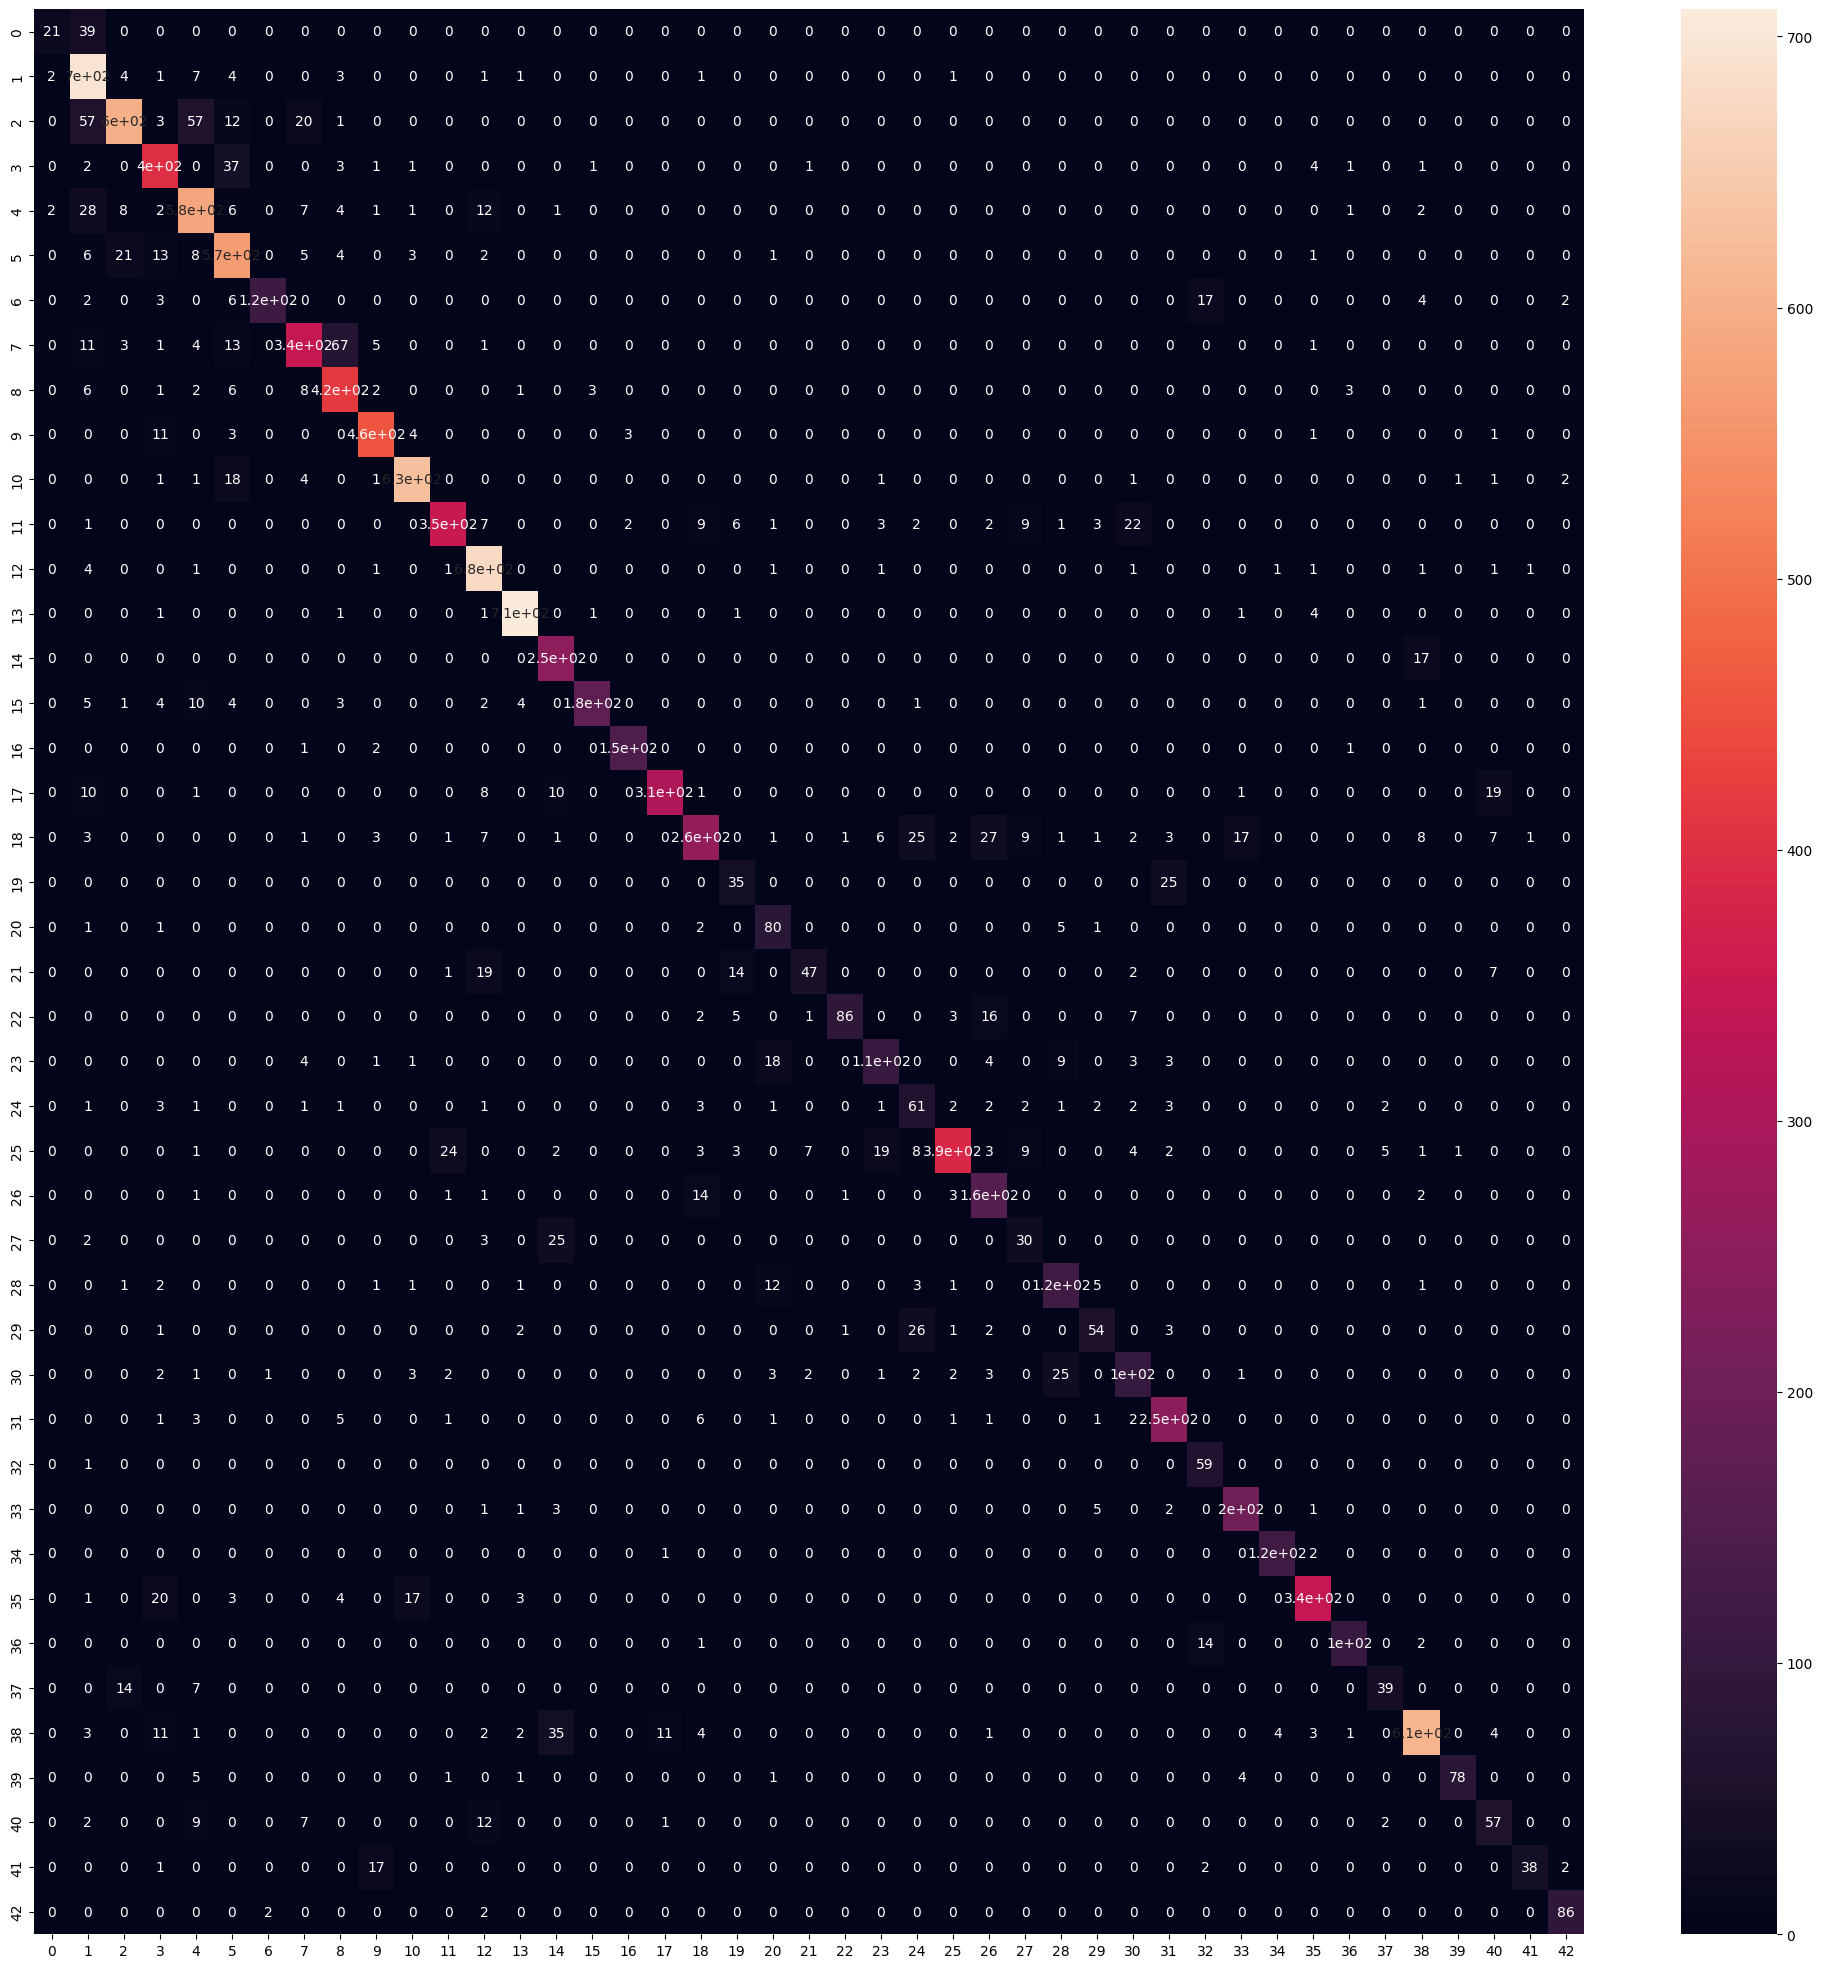

In [32]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, predicted_classes)
plt.figure(figsize = (25, 25))
sns.heatmap(cm, annot = True)

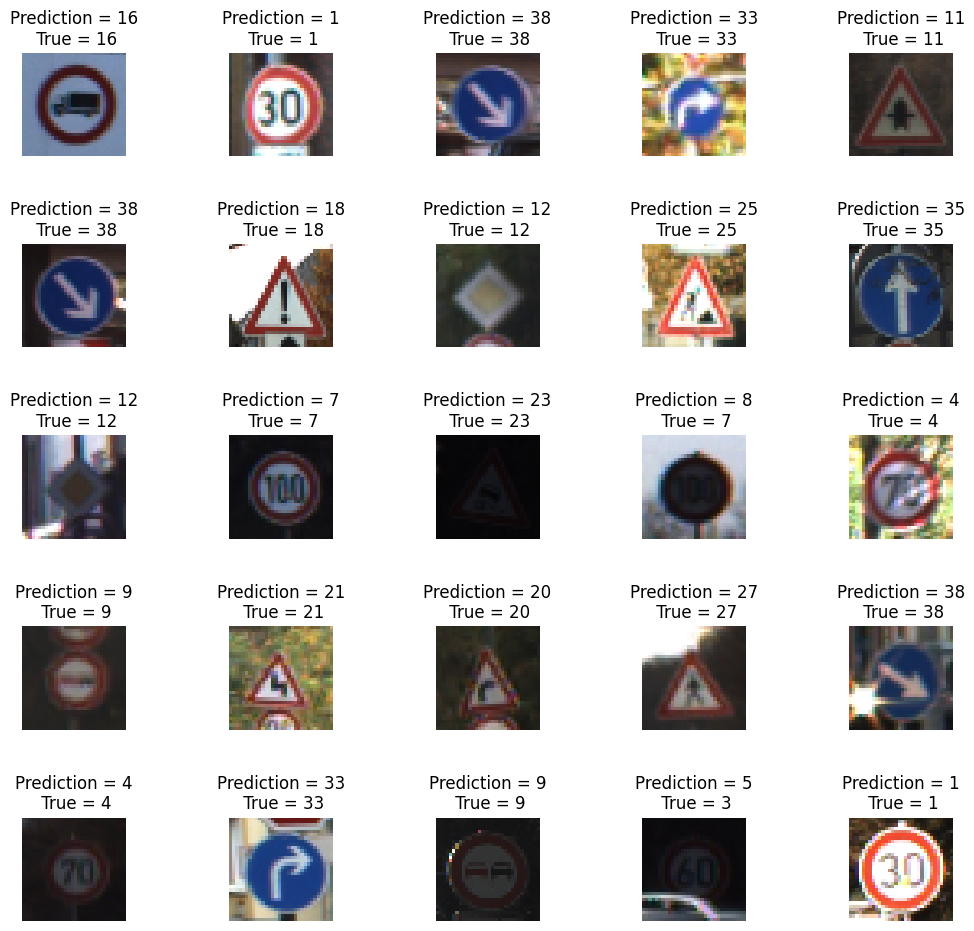

In [33]:
L = 5
W = 5

fig, axes = plt.subplots(L, W, figsize = (12, 12))
axes = axes.ravel()

for i in np.arange(0, L*W):
    axes[i].imshow(X_test[i])
    axes[i].set_title('Prediction = {}\n True = {}'.format(predicted_classes[i], y_true[i]))
    axes[i].axis('off')

plt.subplots_adjust(wspace = 1)

# __Thats All Folks!__